# 3. Scipy及其基本使用

scipy被广泛用于各种科学计算问题中，如求解方程、微分方程、函数的极值优化、插值、拟合、假设检验、傅里叶变换等。可以说，这是科学计算中最重要的一个库函数了。数学建模导论中多数代码其实也是基于scipy进行的。这一章我们需要学习的内容包括：

- [3.1 微积分工具包](./3.1-微积分工具包.md)
- [3.2 优化工具包](./3.2-优化工具包.md)
- [3.3 插值工具包](./3.3-插值工具包.md)
- [3.4 假设检验工具包](./3.4-假设检验工具包.md)
- [3.5 傅里叶变换工具包](./3.5-傅里叶变换工具包.md)

# 3.1 微积分工具包

## 3.1.1 数值积分的求解

计算积分其实我们很早的时候就学习过，可以利用梯形法解决这个问题。梯形法是一种数值积分方法，用于近似计算定积分的值。它通过连接函数在积分区间内各等分点上的值形成的线段（梯形）的面积来近似整个曲线下方的面积。

以下是一个使用Python实现梯形法计算函数定积分的案例。我们将计算函数 $f(x) = x^2$ 在区间 $[0, 1]$ 上的定积分。理论上，这个积分的值是 $\frac{1}{3}$。

In [ ]:
def trapezoidal_rule(f, a, b, n):
    h = (b - a) / n  # 每个梯形的宽度
    s = 0.5 * (f(a) + f(b))  # 第一个和最后一个梯形面积，每个只计算一半
    
    # 计算中间梯形的面积
    for i in range(1, n):
        x = a + i * h
        s += f(x)
    
    # 总面积是所有梯形面积的和
    s *= h
    
    return s

# 定义被积分的函数
def f(x):
    return x**2

# 计算定积分
a, b = 0, 1  # 积分区间
n = 100  # 分割的梯形数量，数量越多，结果越精确

# 调用梯形法函数
integral_approx = trapezoidal_rule(f, a, b, n)

print(f"使用梯形法（n={n}）计算的定积分近似值为: {integral_approx}")
print(f"理论值为: 1/3 = {1/3}")

在这个例子中，`trapezoidal_rule` 函数接收一个函数 `f`、积分区间的下限 `a` 和上限 `b`，以及将区间分割成的梯形数量 `n`。函数首先计算每个梯形的宽度 `h`，然后计算第一个和最后一个梯形（只计算一半）的面积，并累加中间所有梯形的面积。最后，将总面积乘以梯形的宽度 `h` 得到定积分的近似值。你可以通过改变 `n` 的值来观察近似值如何随着梯形数量的增加而接近理论值 $\frac{1}{3}$。

`scipy.integrate` 模块是 SciPy 库中用于数值积分的一个重要部分，它提供了多种数值积分求解的函数，能够处理从简单的一维积分到复杂的多重积分等问题。以下是一些常用的数值积分求解函数及其使用方法，并给出相应的例子。

`quad` 函数用于计算一维函数的定积分。其基本用法是 `scipy.integrate.quad(func, a, b, args=(), full_output=0, epsabs=1.49e-08, epsrel=1.49e-08, limit=50, points=None, weight=None, wvar=None, wopts=None, maxp1=50, limlst=50)`，其中 `func` 是被积函数，`a` 和 `b` 是积分的上下限，`args` 是传递给函数的额外参数（如果有的话）。

**例子**：计算函数 $f(x) = x^2$ 在区间 $[0, 1]$ 上的定积分。

In [ ]:
from scipy.integrate import quad
import numpy as np

def f(x):
    return x**2

result, error = quad(f, 0, 1)
print(f"Integral: {result}, Error: {error}")

`dblquad` 函数用于计算二维函数的二重积分。其基本形式是 `scipy.integrate.dblquad(func, a, b, gfun, hfun, args=(), epsabs=1.49e-08, epsrel=1.49e-08)`，其中 `func` 是被积函数（通常接受两个变量），`a` 和 `b` 是第一个积分变量的上下限，`gfun` 和 `hfun` 是第二个积分变量的上下限函数（这两个函数以第一个积分变量为自变量）。

**例子**：计算二重积分 $\int_{0}^{1} \int_{0}^{x} x y \, dy \, dx$。

In [ ]:
from scipy.integrate import dblquad

def f(y, x):
    return x * y

def g(x):
    return 0

def h(x):
    return x

result, error = dblquad(f, 0, 1, g, h)
print(f"Integral: {result}, Error: {error}")

`tplquad` 函数用于计算三维函数的三重积分。它的用法与 `dblquad` 类似，但增加了对第三个积分变量的处理。而`nquad` 函数提供了更一般的接口，用于计算任意维度的多重积分。它允许用户指定每个积分变量的上下限以及被积函数。

`trapz` 函数使用梯形法则来计算给定数据点的数值积分。它特别适用于对离散数据进行积分，如实验数据或数值解。

**例子**：计算由点集定义的函数在给定区间上的积分。

In [ ]:
from scipy.integrate import trapz
import numpy as np

# 假设的函数值和对应的x
# 假设的数据点  
x = np.linspace(0, 1, 100)  # 均匀分布的x值  
y = x**2  # 对应的函数值  
  
# 使用trapz计算数值积分  
result = trapz(y, x)  
print(f"Integral approximation: {result}")

在这个例子中，`trapz` 函数通过梯形法则计算了由 `x` 和 `y` 定义的函数在区间 `[0, 1]` 上的数值积分。这里，`x` 是积分变量的样本点，`y` 是对应的函数值。`trapz` 函数直接接受 `y` 数组和 `x` 数组作为输入，并返回积分的近似值。 

## 3.1.2 常微分方程的数值解

微分方程的数值解是什么样子的呢？虽然大多数微分方程没有解析解，但解析式也并不是唯一可以表示函数的形式。函数的表示还可以用列表法和作图法来表示，而微分方程的数值解也正是像列表一样针对自变量数组中的每一个取值给出相对精确的因变量值。

`scipy.integrate.odeint` 是 SciPy 库中用于求解常微分方程（ODE）初值问题的一个函数。它基于 FORTRAN 的 ODEPACK 库中的 LSODA 方法，能够处理刚性和非刚性系统。其基本用法如下：

In [4]:
scipy.integrate.odeint(func, y0, t, args=(), Dfun=None, col_deriv=0, full_output=0, ...)

SyntaxError: positional argument follows keyword argument (3512497811.py, line 1)

- **func**：导数函数，即 y 关于 t 的导数，形式为 `func(y, t, *args)`，其中 `y` 是函数值向量，`t` 是时间，`*args` 是传递给函数的额外参数。
- **y0**：初始条件，即 t=t0 时的 y 值。
- **t**：一个序列，表示求解函数值对应的时间点。序列的第一个元素对应于初始时间 t0，且时间序列必须是单调递增或单调递减的。
- **args**：一个元组，包含传递给 func 的额外参数。

**1. 一般的一阶常微分方程**

**例子**：求解 dy/dt = sin(t^2)，初始条件 y(0) = 1。

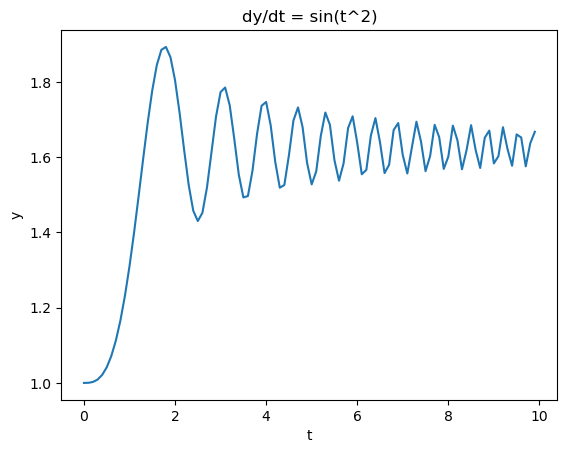

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

def dy_dt(y, t):
    return np.sin(t**2)

y0 = [1]
t = np.arange(0, 10, 0.1)
y = odeint(dy_dt, y0, t)

plt.plot(t, y)
plt.xlabel('t')
plt.ylabel('y')
plt.title('dy/dt = sin(t^2)')
plt.show()

![fig1](./src/1.png)

**2. 常微分方程组**

**例子**：SEIR 模型（传染病模型），包含四个变量 S（易感者）、E（暴露者）、I（感染者）、R（康复者）。

$$
N \frac{\mathrm{d}s}{\mathrm{d}t} = -N \lambda si, \\[0.5em]
N \frac{\mathrm{d}e}{\mathrm{d}t} = N \lambda si - N \delta e, \\[0.5em]
N \frac{\mathrm{d}i}{\mathrm{d}t} = N \delta e - N \mu i, \\[0.5em]
N \frac{\mathrm{d}r}{\mathrm{d}t} = -N \mu i, \\[0.5em]
s(t) + e(t) + i(t) + r(t) = 1
$$

In [ ]:
def model(Y, t, N, beta0, days0, beta1, gamma, sigma):
    S, E, I, R = Y
    beta = beta0 if t < days0 else beta1
    dS = -beta * S * I / N
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I
    return [dS, dE, dI, dR]

N = 1000
beta0, beta1, gamma, sigma = 0.857, 0.304, 0.357, 0.312
days0 = 70
daysTotal = 365
T = np.arange(daysTotal)
N0 = [N - 1, 1, 0, 0]  # 初始条件

res = odeint(model, N0, T, args=(N, beta0, days0, beta1, gamma, sigma))

plt.plot(T, res[:, 0], label='S')
plt.plot(T, res[:, 1], label='E')
plt.plot(T, res[:, 2], label='I')
plt.plot(T, res[:, 3], label='R')
plt.legend()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/2.png)

**3. 二阶常微分方程**

对于二阶常微分方程，通常需要将其转化为两个一阶方程组成的方程组。

**例子**：求解 y'' + y = 0，初始条件 y(0) = 1, y'(0) = 0。

令 y1 = y, y2 = y'，则 y1' = y2, y2' = -y1。

In [ ]:
def second_order(y, t):
    y1, y2 = y
    return [y2, -y1]

y0 = [1, 0]  # 初始条件
t = np.arange(0, 10, 0.1)
y = odeint(second_order, y0, t)

plt.plot(t, y[:, 0], label='y')
plt.plot(t, y[:, 1], label='y\'')
plt.legend()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/3.png)

**4. 高阶常微分方程**

关于高阶常微分方程的解法，其基本原理与二阶微分方程相同，即将高阶方程转化为多个一阶微分方程组成的方程组。然而，随着方程阶数的增加，需要引入的变量也会增多，从而使得方程组变得更加复杂。

不过，为了完整性，我将给出一个三阶常微分方程转化为三个一阶微分方程的例子，并展示如何使用`scipy.integrate.odeint`来求解它。

**案例**：考虑三阶常微分方程：

$$ y''' + y'' + y' + y = 0 $$

初始条件为 $y(0) = 1, y'(0) = 0, y''(0) = 0$。

首先，我们定义三个新的变量：

$$ y_1 = y $$
$$ y_2 = y' $$
$$ y_3 = y'' $$

这样，原三阶方程就可以转化为以下三个一阶方程：

$$ y_1' = y_2 $$
$$ y_2' = y_3 $$
$$ y_3' = -y_1 - y_2 - y_3 $$

接下来，我们编写Python代码来求解这个方程组：

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

def third_order(y, t):
    y1, y2, y3 = y
    dy1 = y2
    dy2 = y3
    dy3 = -y1 - y2 - y3
    return [dy1, dy2, dy3]

# 初始条件
y0 = [1, 0, 0]

# 时间点
t = np.arange(0, 10, 0.1)

# 求解
y = odeint(third_order, y0, t)

# 绘图
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t, y[:, 0], label='y')
plt.title('y(t)')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, y[:, 1], label='y\'')
plt.title('y\'(t)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, y[:, 2], label='y\'\'')
plt.title('y\'\'(t)')
plt.grid(True)

plt.tight_layout()
plt.show()


![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/4.png)

在这段代码中，我们首先定义了`third_order`函数，它接受当前的函数值向量`y`和时间`t`作为输入，并返回对应的导数向量。然后，我们设置了初始条件`y0`和时间点`t`，并使用`odeint`函数求解方程组。最后，我们使用Matplotlib库将求解结果绘制成图形，分别展示了$y(t)$、$y'(t)$和$y''(t)$随时间的变化情况。

**案例：洛伦兹系统（Lorenz System）**

洛伦兹系统是一个经典的混沌系统，由三个一阶微分方程组成：

$$ \frac{dx}{dt} = \sigma(y - x) $$
$$ \frac{dy}{dt} = x(\rho - z) - y $$
$$ \frac{dz}{dt} = xy - \beta z $$

其中，$\sigma$、$\rho$和$\beta$是系统的参数。

以下是使用`scipy.integrate.odeint`求解洛伦兹系统的Python代码：

In [ ]:
import numpy as np
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
def dmove(Point, t, sets):
    p, r, b = sets
    x, y, z = Point
    return np.array([p*(y-x), x*(r-z), x*y-b*z])
t = np.arange(0, 30, 0.001)
P1 = odeint(dmove, (0., 1., 0.), t, args=([10., 28., 3.],))
P2 = odeint(dmove, (0., 1.01, 0.), t, args=([10., 28., 3.],)) 
fig = plt.figure()
ax = Axes3D(fig)
ax.plot(P1[:,0], P1[:,1], P1[:,2])
ax.plot(P2[:,0], P2[:,1], P2[:,2])
plt.show()


![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/5.png)

在SciPy库中，除了`odeint`之外，`solve_ivp`和`solve_bvp`也是用于求解常微分方程（ODE）的重要函数，但它们各自适用于不同类型的初值问题（IVP）和边值问题（BVP）。

`solve_ivp`是SciPy中较新的一个函数，用于求解ODE的初值问题。它比`odeint`提供了更多的灵活性和功能，比如能够处理事件（events）和更复杂的积分方法。

**基本用法**：

In [ ]:
from scipy.integrate import solve_ivp

# 定义导数函数
def deriv(t, y):
    # 返回导数dy/dt
    return ...

# 初始条件
y0 = [...]

# 时间点
t_span = (t0, tf)  # 或使用数组形式指定多个时间点

# 调用solve_ivp
sol = solve_ivp(deriv, t_span, y0, method='RK45', t_eval=None, events=None, ...)

# sol.t 是计算的时间点
# sol.y 是对应的解


**例子**：求解简单的线性方程 dy/dt = -2y, y(0) = 1。

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

def deriv(t, y):
    return -2 * y

y0 = [1]
t_span = (0, 5)
t_eval = np.linspace(0, 5, 100)

sol = solve_ivp(deriv, t_span, y0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('y')
plt.title('dy/dt = -2y')
plt.show()


![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/6.png)

`solve_bvp`用于求解ODE的边值问题（BVP），即给定在区间两端的函数值或导数，求解区间内的函数。

**基本用法**：

In [ ]:
from scipy.integrate import solve_bvp

# 定义导数函数
def fun(x, y):
    return np.vstack([...])  # 返回一个列向量，包含所有y_i的导数

# 定义边界条件
def bc(ya, yb):
    return np.array([...])  # 返回边界条件的残差

# 初始网格（可以自动细化）
x = np.linspace(a, b, num)

# 初始猜测解
y = np.zeros((num, len(y0)))  # y0是初始猜测的解向量
y[:, 0] = ...  # 填充初始猜测

# 调用solve_bvp
sol = solve_bvp(fun, bc, x, y, tol=1e-3, solver_options={'disp': True})

# sol.x 是优化后的网格
# sol.y 是对应的解


**注意**：`solve_bvp`需要较复杂的设置，特别是边界条件和初始猜测解，而且它返回的解`sol.y`是针对优化后的网格`sol.x`的。

# 3.2 优化工具包

## 3.2.1 函数的零点与方程的解

`scipy.optimize` 模块包含了一些求解方程根的函数。其中的一些函数，如 `fsolve`、`root` 和 `brentq` 等，可以用来求解方程的根。

`fsolve` 函数使用最小二乘法（通常是 Levenberg-Marquardt 方法）来找到给定函数 `func(x)` 的根，其中 `x` 可以是标量或数组。它适用于求解非线性方程组。

**例子**：求解方程 $x^2 - 612 = 0$

In [ ]:
from scipy.optimize import fsolve

def func(x):
    return x**2 - 612

# 初始猜测
x0 = 10.0

# 求解
solution = fsolve(func, x0)

print(solution)  # 输出结果应该接近24.74（正根）

注意：由于 `fsolve` 可能依赖于初始猜测，它不一定总能找到所有的根或正确的根（尤其是当方程有多个根时）。

`root` 函数提供了更多的灵活性和算法选择来求解方程或方程组。它使用多种算法（如 'hybr', 'lm', 'broyden1', 'broyden2', 'anderson', 'linearmixing', 'diagbroyden', 'excitingmixing', 'krylov', 'df-sane'）来尝试找到函数的根。

**例子**：求解方程组

$$ \begin{cases} 
x^2 + y^2 - 4 = 0 \\
x - y = 1 
\end{cases} $$

In [ ]:
from scipy.optimize import root
import numpy as np

def func(vars):
    x, y = vars
    return [x**2 + y**2 - 4, x - y - 1]

# 初始猜测
x0 = [0, 0]

# 求解
solution = root(func, x0)

print(solution.x)  # 输出结果应该接近 [1.61803399, 0.61803399]（或其他满足方程的解）

`solution.x` 包含了方程的解，`solution.success` 表示是否成功找到解，`solution.message` 提供了关于求解过程的额外信息。

`brentq`, `brenth`, `ridder`, `bisect`等一些函数是专门用于求解一维方程根的函数，它们基于二分法或其改进版本。这些函数通常比 `fsolve` 或 `root` 在一维问题上更快、更稳定。

**例子**：使用 `brentq` 求解方程 $f(x) = x^2 - 2$ 在区间 [1, 2] 上的根。

In [ ]:
from scipy.optimize import brentq

def func(x):
    return x**2 - 2

# 求解
solution = brentq(func, 1, 2)

print(solution)  # 输出结果应该接近sqrt(2)

这些函数要求你提供一个包含根的区间，并且函数在该区间内必须是连续的，且在该区间的两端点上的函数值符号相反。

## 3.2.2 函数的极值优化

`scipy.optimize.brent` 是 SciPy 库中用于求解单变量无约束优化问题的函数，它结合了牛顿法和二分法的优点，既能保证稳定性又能快速收敛，是求解一维搜索问题的首选方法之一。下面通过具体例子来介绍 `scipy.optimize.brent` 的用法。

**示例**

假设我们有一个目标函数 `f(x) = (x - 1)^2`，我们想要找到这个函数的最小值点。这个函数的最小值显然在 `x = 1` 处取得，但我们现在要通过 `scipy.optimize.brent` 来求解它。

In [ ]:
import numpy as np
from scipy.optimize import brent

# 定义目标函数
def f(x):
    return (x - 1)**2

# 使用brent函数求解最小值点
# brack参数指定了搜索算法的开始区间，这里我们选择一个包含最小值的区间
xmin = brent(f, brack=(0, 2))

# 输出结果
print("最小值点 x =", xmin)
print("函数在最小值点的值 =", f(xmin))

在这个例子中，`brent` 函数的第一个参数是目标函数 `f`，第二个参数 `brack` 是一个元组，指定了搜索算法的开始区间。`brent` 函数会在这个区间内寻找函数的最小值点，并返回该点的 `x` 值。在这个例子中，我们选择了区间 `(0, 2)`，它包含了函数的最小值点 `x = 1`。

**注意事项**

1. **区间选择**：在使用 `brent` 函数时，选择合适的搜索区间非常重要。如果区间不包含最小值点，`brent` 可能无法找到正确的最小值点。
2. **参数设置**：`brent` 函数还有其他可选参数，如 `tol`（容忍度，控制收敛精度）、`maxiter`（最大迭代次数）和 `full_output`（是否返回所有输出参数）等。这些参数可以根据需要进行设置。
3. **返回值**：默认情况下，`brent` 只返回最小值点的 `x` 值。如果设置了 `full_output=True`，则会返回所有输出参数，包括最小值点的 `x` 值、函数在最小值点的值、迭代次数和函数评估次数等。

`scipy.optimize.fmin` 是 SciPy 库中的一个优化函数，用于求解无约束多元函数的最小值。该函数通过迭代方法（如Nelder-Mead单纯形法）来寻找函数的最小值点。

- `func`：需要最小化的函数，形式为 `func(x, *args)`。
- `x0`：初始点，可以是一个列表或数组。
- `args`：传递给 `func` 的额外参数，即 `f(x, *args)`。
- `full_output`：是否返回额外的输出信息，默认为 `False`。当设置为 `True` 时，会返回更多关于优化过程的信息。
- `disp`：是否显示优化过程，默认为 `True`，表示在优化过程中会打印消息。
- `maxfun`：最大函数评估次数，默认为 1000。
- `retall`：是否返回所有迭代过程中的函数值，默认为 `False`。

下面通过具体例子来介绍 `scipy.optimize.fmin` 的用法。

**示例**

假设我们有一个二次函数 `f(x) = ax^2 + bx + c`，其中 `a = 1, b = 3, c = 2`，我们想要找到这个函数的最小值点。

In [ ]:
import numpy as np
from scipy.optimize import fmin

# 定义需要最小化的函数
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# 设置初始点
x0 = np.array([1.0])  # 注意：对于一维问题，x0 也需要是数组形式

# 设置函数参数
a, b, c = 1, 3, 2

# 使用 fmin 函数求解最小值
result = fmin(quadratic, x0, args=(a, b, c), full_output=True, disp=True)

# 输出结果
print("最小值点:", result[0])
print("最小值:", result[1])
print("迭代次数:", result[2]['nit'])
print("函数调用次数:", result[2]['nfev'])

**注意事项**

- `scipy.optimize.fmin` 主要依赖于单纯形法，这种方法在处理高维问题时可能效率不高，且对于复杂函数的优化效果可能不如基于梯度的方法。
- 在使用 `fmin` 时，选择合适的初始点 `x0` 对优化结果有很大影响。不恰当的初始点可能导致算法陷入局部最优解或无法收敛。

`scipy.optimize.linprog` 是 SciPy 库中用于解决线性规划问题的函数。它能够处理带有线性等式和不等式约束的最小化问题。以下是 `linprog` 函数的基本用法和一个具体例子。

`linprog` 函数的基本调用格式如下：

In [ ]:
scipy.optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

考虑以下线性规划问题：

最小化目标函数 $ -29x_1 - 45x_2 $，受以下约束条件限制：

- $ x_1 - x_2 - 3x_3 \leq 5 $
- $ -2x_1 + 3x_2 + 7x_3 \leq -10 $
- $ 2x_1 + 8x_2 + x_3 = 60 $
- $ 4x_1 + 4x_2 + x_4 = 60 $
- 所有变量 $ x_1, x_2, x_3, x_4 $ 非负。

为了使用 `linprog` 解决这个问题，我们需要将目标函数转换为最小化形式（已给出），并设置适当的约束。以下是相应的 Python 代码：

In [ ]:
from scipy.optimize import linprog

# 目标函数系数，注意这里是最小化 -29x1 - 45x2，对于 x3 和 x4 的系数为 0
c = [-29, -45, 0, 0]

# 不等式约束的系数矩阵和常数项
A_ub = [[1, -1, -3, 0],
        [-2, 3, 7, -3]]
b_ub = [5, -10]

# 等式约束的系数矩阵和常数项
A_eq = [[2, 8, 1, 0],
        [4, 4, 0, 1]]
b_eq = [60, 60]

# 变量的界限，所有变量非负
bounds = [(0, None), (0, None), (0, None), (0, None)]

# 调用 linprog
result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

# 输出结果
print(result)

这段代码将调用 `linprog` 函数来求解上述线性规划问题，并输出求解结果，包括最优解、目标函数值等信息。

指派问题（Assignment Problem）是一种特殊的线性规划问题，它要求将一组任务分配给一组工人，每个工人只能分配到一个任务，每个任务也只能被一个工人完成，目标是使得总的分配成本（或时间、资源等）最小化。在数学上，这通常表示为一个成本矩阵，其中矩阵的每个元素表示特定工人完成特定任务的成本。

`scipy.optimize.linear_sum_assignment` 是 SciPy 库中用于解决指派问题的函数。它实现了匈牙利算法（也称为KM算法或Kuhn-Munkres算法）的变种，用于找到成本矩阵中的最小成本匹配。

In [ ]:
scipy.optimize.linear_sum_assignment(cost_matrix, maximize=False)

- `cost_matrix`：二维数组，表示成本矩阵。
- `maximize`：布尔值，如果为True，则函数会寻找最大权重的匹配，而不是默认的寻找最小权重的匹配。

函数返回两个一维数组，分别表示行索引和列索引的配对，使得对应的成本之和最小（或最大，如果`maximize=True`）。

假设有三个工人（A, B, C）和三个任务（1, 2, 3），我们需要确定哪个工人应该执行哪个任务，以最小化总成本。成本矩阵如下：

```
  1 2 3
A 4 1 3
B 2 0 5
C 3 2 2

```

在这个矩阵中，元素（i, j）表示工人i完成任务j的成本。

使用 `scipy.optimize.linear_sum_assignment` 来解决这个问题：

In [ ]:
from scipy.optimize import linear_sum_assignment

# 成本矩阵
cost_matrix = [[4, 1, 3],
               [2, 0, 5],
               [3, 2, 2]]

# 求解指派问题
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# 输出结果
print("工人和任务的最优匹配（工人索引, 任务索引）:")
for i in range(len(row_ind)):
    print(f"工人 {chr(ord('A')+i)} -> 任务 {col_ind[i] + 1}")

# 计算最小总成本
min_cost = cost_matrix[row_ind, col_ind].sum()
print(f"最小总成本: {min_cost}")


输出可能是：

```
工人和任务的最优匹配（工人索引, 任务索引）:
工人 A -> 任务 2
工人 B -> 任务 1
工人 C -> 任务 3
最小总成本: 5

```

这表明，为了最小化总成本，应该将任务2分配给工人A，任务1分配给工人B，任务3分配给工人C，这样总成本就是5。

`scipy.optimize.minimize` 是 SciPy 库中用于求解最小化问题的强大函数，它支持无约束优化、有约束优化以及全局优化等多种类型的问题。该函数的基本语法如下：

In [ ]:
scipy.optimize.minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)


参数说明：

- **fun**：需要被最小化的目标函数。
- **x0**：优化变量的初始猜测值，是N维数组对象`ndarray`。
- **args**：可选，传递给目标函数及其导数的额外参数，以元组形式给出。
- **method**：可选，求解问题的方法，应该是预定义算法中的一种（如'Nelder-Mead', 'BFGS', 'L-BFGS-B'等）。如果不指定，将根据问题的性质（如是否有约束或界限）自动选择。
- **jac**：可选，目标函数的雅可比矩阵（一阶偏导）。对于某些方法（如CG, BFGS, Newton-CG等）是必需的或可以加速计算。
- **hess, hessp**：可选，目标函数的Hessian矩阵（二阶导数矩阵）或其乘积。仅适用于某些方法（如Newton-CG, dogleg等）。
- **bounds**：可选，变量的界限。以(min, max)对的形式定义每个优化变量的边界，仅适用于L-BFGS-B, TNC和SLSQP方法。
- **constraints**：可选，约束条件。可以是字典或列表的序列，每个约束包含`type`（'eq'表示等式约束，'ineq'表示不等式约束）、`fun`（定义约束的函数）和`jac`（约束条件的梯度函数，仅对SLSQP有效）等关键字。
- **tol**：可选，终止条件的容忍度，即优化算法的精度。
- **callback**：可选，每次迭代调用的回调函数，可以监控优化过程。
- **options**：可选，字典类型，用于设置优化器的其他选项，如最大迭代次数`maxiter`、是否打印收敛信息`disp`等。

当求解含有约束的极值优化问题时，`scipy.optimize.minimize` 通过设置`bounds`和`constraints`参数来处理这些约束。以下是一个具体的例子，说明如何在有约束条件下使用该函数。

假设我们需要最小化函数 `f(x, y) = (x-1)^2 + (y-2)^2`，同时满足约束条件 `x + 2y >= 1` 和 `x, y` 的取值范围都在 `[0, 2]` 之间。

首先，我们需要定义目标函数和约束条件：

In [ ]:
import numpy as np
from scipy.optimize import minimize

# 目标函数
def objective(x):
    return (x[0] - 1)**2 + (x[1] - 2)**2

# 约束条件
def constraint1(x):
    return x[0] + 2*x[1] - 1

# 定义约束条件为字典列表
con = ({'type': 'ineq', 'fun': constraint1})

# 变量的界限
bounds = [(0, 2), (0, 2)]

# 初始猜测值
x0 = [0, 0]

# 使用minimize求解
res = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=con)

# 打印结果
print(res.x)  # 最优解
print(res.fun)  # 最优解处的函数值
print(res.success)  # 是否成功找到解
print(res.message)  # 终止原因


在这个例子中，我们使用`SLSQP`方法求解带有不等式约束和变量界限的最小化问题。`bounds`参数定义了每个变量的取值范围，`constraints`参数定义了不等式约束条件。最终，`minimize`函数返回了包含优化结果的`OptimizeResult`对象，其中包括最优解`x`、最优解处的函数值`fun`、是否成功找到解的标志`success`以及终止原因的描述`message`。


## 3.2.3 曲线拟合

在Python的`scipy.optimize`模块中，`leastsq`和`curve_fit`是两个常用的函数，用于通过最小二乘法进行数据拟合。

`leastsq`函数是SciPy中用于执行最小二乘拟合的一个函数，它通过最小化误差平方和来找到最佳拟合参数。`leastsq`函数的基本形式为：

In [ ]:
scipy.optimize.leastsq(func, x0, args=(), Dfun=None, full_output=0, col_deriv=0, ftol=1.49012e-08, xtol=1.49012e-08, gtol=0.0, maxfev=0, epsfcn=None, factor=100, diag=None)


其中，`func`是计算误差的函数，`x0`是初始参数估计值，`args`是传递给`func`的其他参数（元组形式）。

**示例**：

假设我们有一组数据点，并希望用二次多项式`f(x) = ax^2 + bx + c`来拟合这些数据。

In [ ]:
import numpy as np
from scipy.optimize import leastsq
import matplotlib.pyplot as plt

# 定义模型函数
def model(x, a, b, c):
    return a * x**2 + b * x + c

# 定义误差函数
def residuals(params, x, y):
    a, b, c = params
    return y - model(x, a, b, c)

# 生成模拟数据
x = np.linspace(-10, 10, 50)
y = model(x, 2, 3, 1) + np.random.normal(0, 2, len(x))  # 添加噪声

# 初始参数估计
initial_params = [0, 0, 0]

# 执行拟合
params, flag = leastsq(residuals, initial_params, args=(x, y))

# 绘制结果
plt.scatter(x, y, label='Data')
plt.plot(x, model(x, *params), label='Fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(params))
plt.legend()
plt.show()


![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/7.png)

`curve_fit`是SciPy中用于曲线拟合的另一个函数，它直接通过非线性最小二乘法来拟合数据。与`leastsq`相比，`curve_fit`的接口更加直观和易用。

**用法概述：**

`curve_fit`函数的基本形式为：

In [ ]:
scipy.optimize.curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=True, bounds=(-inf, inf), method=None, jac=None, **kwargs)


其中，`f`是模型函数，`xdata`和`ydata`分别是自变量和因变量的数据点，`p0`是初始参数估计值。

**示例**：

继续使用上面的二次多项式拟合示例。

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 定义模型函数
def model(x, a, b, c):
    return a * x**2 + b * x + c

# 生成模拟数据
x = np.linspace(-10, 10, 50)
y = model(x, 2, 3, 1) + np.random.normal(0, 2, len(x))  # 添加噪声

# 初始参数估计
p0 = [0, 0, 0]

# 执行拟合
params, pcov = curve_fit(model, x, y, p0=p0)

# 绘制结果
plt.scatter(x, y, label='Data')
plt.plot(x, model(x, *params), label='Fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(params))
plt.legend()
plt.show()


![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/8.png)

在上面的`curve_fit`示例中，我们首先定义了模型函数`model`，该函数接受自变量`x`和三个参数`a`、`b`、`c`，并返回根据二次多项式计算得到的`y`值。然后，我们生成了一组模拟数据，这些数据是通过在真实模型上添加随机噪声得到的。

接下来，我们设置了初始参数估计`p0`，这些参数是我们在开始拟合之前对模型参数的猜测。在这个例子中，我们简单地猜测所有参数都是0。

调用`curve_fit`函数时，我们传入了模型函数`model`、自变量数据`x`、因变量数据`y`以及初始参数估计`p0`。`curve_fit`函数会找到最佳拟合参数，这些参数使得模型函数与数据之间的误差平方和最小。

拟合完成后，`curve_fit`返回两个值：最佳拟合参数`params`和这些参数的协方差矩阵`pcov`（如果需要的话）。在这个例子中，我们只关心最佳拟合参数`params`，并使用它们来绘制拟合曲线。

最后，我们使用`matplotlib`库来绘制原始数据点和拟合曲线，并通过图例显示了拟合得到的参数值。这样，我们就可以直观地看到拟合的效果，并验证模型是否能够准确地描述数据。

# 3.3 插值工具包

## 3.3.1 一维插值

`scipy.interpolate` 模块提供了多种一维和多维插值方法。在一维插值中，你通常想要根据一组已知的数据点（x 坐标和对应的 y 值）来估计或预测其他未知 x 坐标处的 y 值。以下是一些常用的一维插值方法的介绍，并通过示例来说明它们的使用。

**常用的一维插值方法**

1. **线性插值 (`interp1d` with `kind='linear'`)**： 这是最简单也是最常用的插值方法，它通过连接数据点之间的直线来估计未知点的值。

2. **多项式插值 (`interp1d` with `kind='polyint'` 或直接使用 `PPoly`/`BPoly`)**： 通过一个多项式来拟合数据点，然后使用该多项式来估计未知点的值。注意，`interp1d` 中 `kind='polyint'` 并不是一个直接的选项，这里指的是可以使用高阶多项式（如 `kind=3` 表示三次多项式）来插值，但通常建议使用较低阶多项式以避免龙格现象（Runge's phenomenon）。

3. **样条插值 (`interp1d` with `kind='cubic'` 或使用 `splrep`, `splev`)**： 使用分段多项式（通常是三次多项式）来插值，这些多项式在每个数据点之间的区间内是平滑的。

**示例：使用 `interp1d` 进行线性插值和样条插值**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 定义数据点
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 0.8, 0.9, 0.1, -0.8, -1])

# 使用线性插值
f_linear = interp1d(x, y, kind='linear')

# 使用三次样条插值
f_cubic = interp1d(x, y, kind='cubic')

# 生成新的x值以进行插值
x_new = np.linspace(0, 5, 400)

# 计算插值结果
y_linear = f_linear(x_new)
y_cubic = f_cubic(x_new)

# 绘制结果
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Data points')
plt.plot(x_new, y_linear, '-', label='Linear interpolation')
plt.plot(x_new, y_cubic, '--', label='Cubic spline interpolation')
plt.legend()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/9.png)

在这个例子中，我们首先定义了一组数据点 `x` 和 `y`，然后使用 `interp1d` 函数分别进行了线性插值和三次样条插值。通过生成一组新的 `x` 值 `x_new`，我们计算了在这些新 `x` 值处的插值结果 `y_linear` 和 `y_cubic`，并使用 Matplotlib 库将原始数据点和插值结果绘制出来。

从图中可以看出，线性插值通过直线连接数据点，而三次样条插值则提供了更平滑的曲线，尤其是在数据点之间的区域。这对于需要平滑过渡或避免过拟合的场合非常有用。


## 3.3.2 二维插值

`scipy.interpolate.interp2d` 是 `scipy.interpolate` 模块中的一个函数，用于对二维数据进行插值。这个函数接受一组二维数据点的 x 坐标、y 坐标以及对应的 z 值（即函数值），并返回一个插值函数对象。这个插值函数对象可以在新的 x 和 y 坐标上计算 z 的估计值。

下面是一个使用 `interp2d` 的具体例子：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp2d

# 定义已知数据点的 x 和 y 坐标
x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 2, 3])

# 创建一个网格化的 x 和 y 坐标（这里为了简单起见，我们使用相同的 x 和 y 坐标，但通常它们会是不同的）
x, y = np.meshgrid(x, y)

# 定义这些坐标点对应的 z 值（这里我们创建一个简单的二维数组作为示例）
z = np.array([[0, 1, 2, 3],
              [1, 2, 3, 4],
              [2, 3, 4, 5],
              [3, 4, 5, 6]])

# 注意：由于 x 和 y 是通过 meshgrid 创建的，它们是二维数组。但是 interp2d 需要的是一维数组作为 x 和 y 的坐标。
# 因此，我们需要将 x 和 y 数组展平，并将 z 数组视为这些坐标点上的值。
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()

# 使用 interp2d 创建插值函数对象
# kind 参数指定了插值方法，这里我们使用 'linear'（线性插值），但也可以尝试 'cubic'（三次插值）等
f = interp2d(x_flat, y_flat, z_flat, kind='linear')

# 现在我们想要在新的 x 和 y 坐标上进行插值
# 假设我们想要在一个更细的网格上进行插值
x_new = np.linspace(0, 3, 10)
y_new = np.linspace(0, 3, 10)
x_new, y_new = np.meshgrid(x_new, y_new)

# 注意：interp2d 需要的 x 和 y 是一维数组，因此我们需要将它们展平以匹配输入数据的形状
# 但由于我们是在整个网格上进行插值，我们可以直接使用 x_new.ravel() 和 y_new.ravel() 来获取一维数组
z_new = f(x_new.ravel(), y_new.ravel())

# 由于 z_new 是一维数组，我们需要将其重新塑形为与 x_new 和 y_new 相同的形状
z_new = z_new.reshape((100,100))
x_new = np.linspace(0, 3, 100)
y_new = np.linspace(0, 3, 100)
x_new, y_new = np.meshgrid(x_new, y_new)

# 绘制结果
plt.contourf(x_new, y_new, z_new, cmap='viridis')
plt.colorbar()
plt.scatter(x_flat, y_flat, c=z_flat, s=50, edgecolor='k', marker='o', label='Data points')
plt.legend()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/10.png)

# 3.4 假设检验工具包

## 3.4.1 正态性检验

正态性检验的目的是为了检测一组数据是否服从正态分布，是否表现出正态分布的特性。正态性检验的方法有很多，包括QQ图、KS检验、SW检验、JB检验等等。这里当然不可能把它们全部讲出来，但可以对一些常见方法进行简要介绍。

在`scipy.stats`模块中，进行正态性检验的常用方法包括Shapiro-Wilk检验、Anderson-Darling检验、Jarque-Bera检验等。不过，需要注意的是，`scipy.stats`直接提供了Shapiro-Wilk检验（`shapiro`）和Anderson-Darling检验（`anderson`）的实现。

Shapiro-Wilk检验是一种检验样本是否来自正态分布的方法，它对于小样本数据（n < 50）特别有效。

In [ ]:
from scipy.stats import shapiro

# 假设data是你的样本数据
data = np.random.normal(loc=0, scale=1, size=100)  # 生成一个正态分布的随机样本

# 进行Shapiro-Wilk检验
stat, p = shapiro(data)

# 输出结果
print('统计量W:', stat)
print('P值:', p)

# 根据P值判断，如果P值小于显著性水平（如0.05），则拒绝原假设，认为数据不是正态分布的
if p < 0.05:
    print("样本不是正态分布的")
else:
    print("样本数据很可能是正态分布的")

Anderson-Darling检验是另一种检验数据是否服从特定分布（如正态分布）的方法。它适用于较大的样本量。

In [ ]:
from scipy.stats import anderson

# 假设data是你的样本数据
data = np.random.normal(loc=0, scale=1, size=100)  # 生成一个正态分布的随机样本

# 进行Anderson-Darling检验
result = anderson(data, dist='norm')  # 指定检验的正态分布

# 输出结果
print('统计量:', result.statistic)
print('显著性水平对应的临界值:', result.critical_values)
print('显著性水平:', result.significance_level)

# 注意：Anderson-Darling检验不直接给出P值，而是给出统计量和不同显著性水平下的临界值。
# 你需要比较统计量和临界值来判断是否拒绝原假设。

# 例如，如果统计量大于0.05显著性水平下的临界值，则可能拒绝原假设（数据不是正态分布的）
if result.statistic > result.critical_values[2]:  # 这里的2代表5%显著性水平
    print("样本不是正态分布的")
else:
    print("没有足够的证据拒绝样本是正态分布的假设")

## 3.4.2 几种典型的假设检验

在`scipy.stats`模块中，你可以进行多种统计检验，包括卡方独立性检验、独立样本t检验、配对样本t检验、方差分析（ANOVA）等。但是，需要注意的是，`scipy.stats`直接提供了卡方独立性检验、独立样本t检验和配对样本t检验的函数，而方差分析（ANOVA）通常使用`scipy.stats.f_oneway`，而事后多重比较（如Tukey's HSD）则可能需要使用`statsmodels`或其他库。下面我将分别给出这些检验的示例代码。

### 1. 卡方独立性检验

卡方独立性检验用于检验两个分类变量是否独立。卡方独立性检验统计的是离散的相关关系，因为得不得肺癌只有两类离散取值：得或者不得，抽不抽烟也只有两类取值：抽或者不抽。两两组合就有四类人群。统计不同的人群可以列出一个列联表，构造的统计量也是一个服从卡方分布的统计量，因其服从卡方分布所以叫它卡方独立性检验。

In [ ]:
from scipy.stats import chi2_contingency

# 假设有一个2x2的列联表
observed = np.array([[10, 20], [30, 40]])

# 进行卡方独立性检验
chi2, p, dof, expected = chi2_contingency(observed)

print(f'Chi-squared: {chi2}, p-value: {p}')

# 如果p值小于显著性水平（如0.05），则拒绝独立性假设
if p < 0.05:
    print("两个分类变量不独立")
else:
    print("两个分类变量独立")

### 2. 独立样本t检验

独立样本t检验用于比较两个独立样本的均值是否存在显著差异。独立样本t检验适合检验两组不同的样本在某一方面的表现差异。例如，想探究高一学生2000米跑成绩和高三学生2000米跑的成绩差异，这种情况就适合使用独立样本t检验。因为高一学生和高三学生是两批不同的人，它们的男女比例不同、年龄不同、平均身高体重不同……甚至连人数都是不一样的！区别独立样本和配对样本一个最根本的特征就是样本是同一批还是不同的两批，而最直观的特征就是两组样本的数量是否相同。数量不同的两组样本不能构成配对样本。

In [ ]:
from scipy.stats import ttest_ind

# 假设有两个独立样本
sample1 = np.random.normal(loc=0, scale=1, size=100)
sample2 = np.random.normal(loc=0.5, scale=1, size=100)

# 进行独立样本t检验
t_stat, p_val = ttest_ind(sample1, sample2)

print(f'T-statistic: {t_stat}, p-value: {p_val}')

# 如果p值小于显著性水平（如0.05），则拒绝零假设（两个样本均值相等）
if p_val < 0.05:
    print("两个样本的均值存在显著差异")
else:
    print("两个样本的均值没有显著差异")

### 3. 配对样本t检验

配对样本t检验用于比较同一组对象在不同条件下的均值是否存在显著差异。配对样本t检验适合检验同一组样本在进行某一操作前后的状态差异。例如，想探究一笼健康的小白鼠在注射某神经亢奋药物前后的神经活跃性差异，这种情况就适合使用配对样本t检验。因为在注射药物前后，小白鼠始终是同一批小白鼠，没有新的老鼠混进来也没有老鼠逃走，它们只是需要被检测注射药物前后两种不同的状态。

In [ ]:
from scipy.stats import ttest_rel

# 假设有一组对象在两种条件下的测量结果
before = np.random.normal(loc=0, scale=1, size=100)
after = np.random.normal(loc=0.3, scale=1, size=100)

# 进行配对样本t检验
t_stat, p_val = ttest_rel(before, after)

print(f'T-statistic: {t_stat}, p-value: {p_val}')

# 如果p值小于显著性水平（如0.05），则拒绝零假设（两种条件下的均值相等）
if p_val < 0.05:
    print("两种条件下的均值存在显著差异")
else:
    print("两种条件下的均值没有显著差异")

### 4. 方差分析（ANOVA）

方差分析（ANOVA）可以用于两个样本及以上样本之间的比较，并可以用于分离各有关因素并估计其对总变异的作用，以及分析因素间的交互作用。方差分析可以用于均数差别的显著性检验、分离各有关因素并估计其对总变异的作用、分析因素间的交互作用和方差齐性检验等。

方差分析的基本思想是通过比较不同组别之间的平均数差异来确定这些差异是否显著。它利用方差度量每个组别的变异，并将这些变异分解为组内和组间变异。通过比较组间变异和组内变异的比例，可以判断不同组别之间的平均数差异是否具有统计意义。如果组间变异的比例较大，说明组别之间的差异显著。反之，如果组内变异的比例较大，说明组别之间的差异不显著，可能是由于随机误差的影响。因此，方差分析可以帮助我们确定不同因素对实验结果的影响程度，进一步揭示数据背后的规律和机制。方差可以分解成三个部分：*Q*=*Q*<sub>1</sub>+*Q*<sub>2</sub>+*Q*<sub>3</sub>。其中，*Q*<sub>1</sub>是指多个控制变量单独作用引起的平方和，可以用来描述每个变量单独是否存在影响；*Q*<sub>2</sub>是指多个控制变量交互作用引起的离差平方和，可以用来描述变量之间是否存在协同效应或交互；*Q*<sub>3</sub>则是随机扰动，用于反映结果受随机影响的程度。

在Python中，可以通过scipy.stats.f_oneway函数实现方差分析。

In [ ]:
from scipy.stats import f_oneway

# 假设有三组样本
group1 = np.random.normal(loc=0, scale=1, size=100)
group2 = np.random.normal(loc=0.5, scale=1, size=100)
group3 = np.random.normal(loc=1, scale=1, size=100)

# 进行ANOVA
f_stat, p_val = f_oneway(group1, group2, group3)

print(f'F-statistic: {f_stat}, p-value: {p_val}')

# 如果p值小于显著性水平（如0.05），则拒绝零假设（所有组的均值相等）
if p_val < 0.05:
    print("至少两组的均值存在显著差异")
else:
    print("所有组的均值没有显著差异")

# 3.5 傅里叶变换工具包

## 3.5.1 快速傅里叶变换

快速傅里叶变换（FFT）是离散傅里叶变换（DFT）的一种高效算法，其核心在于通过递归或迭代的方式将DFT的计算复杂度从$O(N^2)$降低到$O(N \log N)$。

DFT的定义为：
$$ X[k] = \sum_{n=0}^{N-1} x[n] e^{-2\pi i \frac{kn}{N}} $$
其中，$x[n]$是时域信号，$X[k]$是对应的频域表示，$N$是信号的长度。

FFT通过分解信号为更小的部分，并利用旋转因子$W_N^{nk} = e^{-2\pi i \frac{nk}{N}}$的对称性和周期性来减少计算量。具体地，FFT算法如按时间抽取（DIT）可以表示为：

1. 将$x[n]$分为偶数序列$x_0[n]$和奇数序列$x_1[n]$。
2. 分别计算$X_0[k]$和$X_1[k]$，即$x_0[n]$和$x_1[n]$的DFT。
3. 利用蝶形运算合并结果，得到$X[k]$。

蝶形运算的公式可以简化为：
$$ X[k] = X_0[k] + W_N^k X_1[k] $$
$$ X[k+N/2] = X_0[k] - W_N^k X_1[k] $$

这里，$W_N^k$是旋转因子，$k$是当前迭代的频率索引，$N$是序列长度。每一级迭代都会将序列长度减半，并产生新的旋转因子，直到整个序列被完全处理。

在Python中，`scipy.fft`模块提供了快速傅里叶变换（FFT）的实现。以下是一个使用`scipy.fft.fft`函数进行快速傅里叶变换的示例代码。我们将对一个简单的离散时间信号进行FFT，并绘制其频谱。

你可以使用以下代码进行FFT并绘制频谱：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 创建一个简单的信号：一个频率为50 Hz的正弦波，采样率为1000 Hz，持续1秒钟
fs = 1000  # 采样率
T = 1  # 信号时长
t = np.linspace(0, T, int(fs*T), endpoint=False)  # 时间向量
f = 50  # 信号频率
signal = 0.7*np.sin(2*np.pi*f*t)  # 生成信号

# 进行快速傅里叶变换
yf = fft(signal)

# 获取FFT的频率轴
xf = fftfreq(len(yf), 1/fs)

# 由于FFT结果是对称的，我们只取一半进行绘图
N = len(yf) // 2
yf = yf[:N]
xf = xf[:N]

# 绘制频谱的幅度（绝对值）
plt.figure()
plt.plot(xf, np.abs(yf))
plt.title('Single-Sided Amplitude Spectrum of X(t)')
plt.xlabel('f (Hz)')
plt.ylabel('|Y(f)|')
plt.grid()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/11.png)

在这个例子中：

1. 我们首先生成了一个简单的正弦波信号，其频率为50 Hz，采样率为1000 Hz，持续时间为1秒。
2. 使用`scipy.fft.fft`函数对该信号进行FFT变换。
3. 使用`scipy.fft.fftfreq`函数计算FFT的频率轴。
4. 由于FFT的结果是对称的（对于实数输入信号），我们只取了一半的频率轴和对应的FFT结果来绘制频谱。
5. 使用`matplotlib`绘制了信号的频谱图，其中横轴是频率（Hz），纵轴是FFT结果的幅度（绝对值）。

这样，你就可以看到信号在频域中的表示，即其在不同频率下的成分强度。在这个例子中，你应该能够看到一个明显的峰值在50 Hz处，这是原始信号中正弦波的频率。


## 3.5.2 简单的信号滤波

在Python中，使用`scipy.fft`和`scipy.signal`进行信号滤波通常涉及以下几个步骤：

1. 对信号进行快速傅里叶变换（FFT）。
2. 设计一个滤波器（例如低通、高通、带通或带阻滤波器），并在频域中应用它。
3. 对滤波后的频域信号进行逆快速傅里叶变换（IFFT）以回到时域。

这里我将用Python代码展示四种常见的滤波方式：低通滤波、高通滤波、带通滤波和带阻滤波。由于直接在频域手动操作（如之前的示例所示）通常不是最优选择，这里我将使用`scipy.signal`中提供的时域滤波函数。

以下是使用`scipy.signal`进行四种滤波方式的示例代码：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

# 创建一个测试信号：叠加了一个低频和一个高频正弦波
fs = 1000  # 采样率
T = 1  # 信号时长
t = np.linspace(0, T, int(fs*T), endpoint=False)
f1, f2 = 50, 200  # 两个正弦波的频率
signal = 0.7*np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)

# -------------------------- 低通滤波 --------------------------
# 设计低通滤波器
nyq = 0.5 * fs
cutoff = 80
low = cutoff / nyq
b_low, a_low = butter(N=3, Wn=low, btype='low', analog=False)
filtered_signal_low = lfilter(b_low, a_low, signal)

# -------------------------- 高通滤波 --------------------------
# 设计高通滤波器
high = 120 / nyq
b_high, a_high = butter(N=3, Wn=high, btype='high', analog=False)
filtered_signal_high = lfilter(b_high, a_high, signal)

# -------------------------- 带通滤波 --------------------------
# 设计带通滤波器
low_b = 60 / nyq
high_b = 100 / nyq
b_band, a_band = butter(N=3, Wn=[low_b, high_b], btype='band', analog=False)
filtered_signal_band = lfilter(b_band, a_band, signal)

# -------------------------- 带阻滤波 --------------------------
# 设计带阻滤波器
low_s = 150 / nyq
high_s = 180 / nyq
b_stop, a_stop = butter(N=3, Wn=[low_s, high_s], btype='bandstop', analog=False)
filtered_signal_stop = lfilter(b_stop, a_stop, signal)

# 绘制结果
plt.figure(figsize=(12, 8))

plt.subplot(5, 1, 1)
plt.plot(t, signal)
plt.title('Original Signal')
plt.xlabel('Time [s]')

plt.subplot(5, 1, 2)
plt.plot(t, filtered_signal_low)
plt.title('Lowpass Filtered Signal')
plt.xlabel('Time [s]')

plt.subplot(5, 1, 3)
plt.plot(t, filtered_signal_high)
plt.title('Highpass Filtered Signal')
plt.xlabel('Time [s]')

plt.subplot(5, 1, 4)
plt.plot(t, filtered_signal_band)
plt.title('Bandpass Filtered Signal')
plt.xlabel('Time [s]')

plt.subplot(5, 1, 5)
plt.plot(t, filtered_signal_stop)
plt.title('Bandstop Filtered Signal')
plt.xlabel('Time [s]')

plt.tight_layout()
plt.show()

![](C:/Users/马世拓/Desktop/数学建模导论春2023/Python科学计算/chap3/src/12.png)

在这个示例中，我使用了Butterworth滤波器（`scipy.signal.butter`函数），因为它在通带和阻带之间提供了平滑的过渡。然后，我使用`scipy.signal.lfilter`函数在时域中应用这些滤波器。每种滤波器的设计参数（如截止频率）都是根据测试信号的频率成分和所需的滤波效果来选择的。在实际应用中，你可能需要根据具体情况调整这些参数。此外，虽然我没有直接展示滤波器的频率响应图，但你可以使用`scipy.signal.freqz`函数来绘制它们，以便更好地了解滤波器的性能。